<a href="https://colab.research.google.com/github/Leoren04/finetuning-t5-question-answering/blob/main/notebooks/finetuning_t5_squad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤗 UAS Deep Learning — Task 2
# Fine-Tuning T5-base for Question Answering (SQuAD)

---

**Nama:** Rakha Primindra Danuatmaja  
**NIM:** 1103223001  
**Kelas:** TK-46-GAB (Deep Learning)  
**Tanggal:** 20 Juni 2026

---

## Tujuan
Notebook ini mengimplementasikan **fine-tuning T5-base (Text-to-Text Transfer Transformer)** untuk tugas **Question Answering** menggunakan dataset **SQuAD (Stanford Question Answering Dataset)**. T5 diperlakukan sebagai model Seq2Seq — baik pertanyaan maupun jawaban direpresentasikan sebagai teks.

## Arsitektur T5
T5 menggunakan paradigma **Text-to-Text**: semua tugas NLP diframe sebagai konversi teks-ke-teks.
- **Input**: `question: [pertanyaan] context: [konteks]`
- **Output**: Teks jawaban yang di-generate secara autoregressive

## Pipeline
1. Setup & Instalasi
2. Load Dataset SQuAD
3. Eksplorasi Data (EDA)
4. Preprocessing & Tokenisasi
5. Fine-tuning T5-base
6. Evaluasi (Exact Match & F1)
7. Inference & Demo
8. Analisis & Kesimpulan

## 1. Setup & Instalasi

In [ ]:
# !pip install transformers datasets evaluate accelerate sentencepiece rouge_score -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import re
import string
from collections import Counter

from transformers import (
    T5ForConditionalGeneration,
    T5TokenizerFast,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from datasets import load_dataset
import evaluate

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print('\n✅ Semua library berhasil di-import!')

Device: cuda
GPU: Tesla T4

✅ Semua library berhasil di-import!


## 2. Load Dataset SQuAD

SQuAD adalah dataset QA yang terdiri dari pasangan konteks, pertanyaan, dan jawaban span dari artikel Wikipedia.

In [ ]:
print('Loading SQuAD dataset dari HuggingFace...')
squad = load_dataset('rajpurkar/squad')

print(f'Dataset structure:')
print(squad)
print(f'\nTrain size: {len(squad["train"]):,}')
print(f'Val size:   {len(squad["validation"]):,}')

Loading SQuAD dataset dari HuggingFace...
Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

Train size: 87,599
Val size:   10,570


In [ ]:
# Lihat contoh data
sample = squad['train'][0]
print('=== Contoh Data SQuAD ===')
print(f'\nContext  : {sample["context"][:300]}...')
print(f'\nQuestion : {sample["question"]}')
print(f'\nAnswer   : {sample["answers"]["text"]}')
print(f'Start pos: {sample["answers"]["answer_start"]}')

=== Contoh Data SQuAD ===

Context  : Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is ...

Question : To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?

Answer   : ['Saint Bernadette Soubirous']
Start pos: [515]


## 3. Eksplorasi Data (EDA)

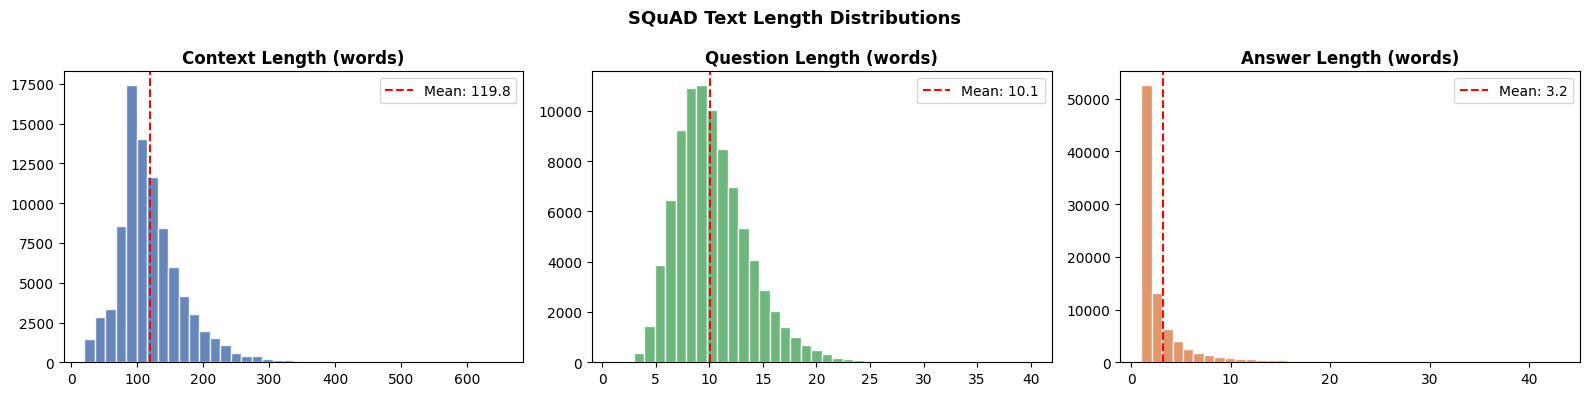

        context_len  question_len    answer_len
count  87599.000000  87599.000000  87599.000000
mean     119.763125     10.061108      3.162159
std       49.365000      3.559230      3.392334
min       20.000000      1.000000      1.000000
25%       89.000000      8.000000      1.000000
50%      110.000000     10.000000      2.000000
75%      142.000000     12.000000      3.000000
max      653.000000     40.000000     43.000000


In [ ]:
import os

# Analisis panjang pertanyaan, konteks, dan jawaban
train_df = pd.DataFrame({
    'context_len':  [len(x['context'].split()) for x in squad['train']],
    'question_len': [len(x['question'].split()) for x in squad['train']],
    'answer_len':   [len(x['answers']['text'][0].split()) for x in squad['train']]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cols = ['context_len', 'question_len', 'answer_len']
titles = ['Context Length (words)', 'Question Length (words)', 'Answer Length (words)']
colors = ['#4C72B0', '#55A868', '#DD8452']

for ax, col, title, color in zip(axes, cols, titles, colors):
    ax.hist(train_df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(train_df[col].mean(), color='red', linestyle='--',
               label=f'Mean: {train_df[col].mean():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('SQuAD Text Length Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()

# Ensure the directory exists before saving the figure
reports_dir = '../reports'
os.makedirs(reports_dir, exist_ok=True)
plt.savefig(os.path.join(reports_dir, 'squad_eda.png'), dpi=150, bbox_inches='tight')
plt.show()

print(train_df.describe())

## 4. Preprocessing & Tokenisasi

T5 menggunakan format input: `question: {q} context: {c}` dan target: `{jawaban}`

In [ ]:
MODEL_NAME = 't5-base'
MAX_INPUT_LENGTH = 512   # Context + question bisa panjang
MAX_TARGET_LENGTH = 64   # Jawaban SQuAD biasanya pendek

print(f'Loading T5 tokenizer: {MODEL_NAME}')
tokenizer = T5TokenizerFast.from_pretrained(MODEL_NAME)

def preprocess_function(examples):
    """
    Preprocess SQuAD untuk T5:
    - Input: 'question: {q} context: {c}'
    - Target: '{answer text}'
    """
    inputs = [
        f'question: {q}  context: {c}'
        for q, c in zip(examples['question'], examples['context'])
    ]
    # Ambil jawaban pertama (bisa ada beberapa dalam SQuAD)
    targets = [ans['text'][0] for ans in examples['answers']]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

    # Tokenize targets directly using text_target argument
    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs['labels'] = labels['input_ids']
    return model_inputs

# Subsample untuk efisiensi (T5-base besar, full SQuAD bisa lama sekali)
TRAIN_SIZE = 8000
VAL_SIZE   = 1000

print(f'Subsampling: {TRAIN_SIZE} train, {VAL_SIZE} val')
small_train = squad['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
small_val   = squad['validation'].shuffle(seed=SEED).select(range(VAL_SIZE))

print('Tokenisasi dataset...')
tokenized_train = small_train.map(preprocess_function, batched=True,
                                   remove_columns=squad['train'].column_names)
tokenized_val   = small_val.map(preprocess_function, batched=True,
                                 remove_columns=squad['validation'].column_names)

print(f'Train tokenized: {len(tokenized_train):,}')
print(f'Val tokenized:   {len(tokenized_val):,}')

Loading T5 tokenizer: t5-base
Subsampling: 8000 train, 1000 val
Tokenisasi dataset...


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train tokenized: 8,000
Val tokenized:   1,000


## 5. Fine-Tuning T5-base

In [ ]:
print(f'Loading model: {MODEL_NAME}')
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,} (~{total_params/1e6:.0f}M)')

# Data collator khusus untuk Seq2Seq (menangani padding label juga)
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,  # Ignore padding dalam loss computation
    pad_to_multiple_of=8 if device == 'cuda' else None
)

Loading model: t5-base


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Total parameters: 222,903,552 (~223M)


In [ ]:
# Metrik evaluasi: Exact Match dan F1 (standard QA metrics)
def normalize_answer(s):
    """Lowercase, hapus punctuation dan artikel (standar SQuAD evaluation)."""
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        return ''.join(ch for ch in text if ch not in string.punctuation)
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_exact_match(prediction, ground_truth):
    return normalize_answer(prediction) == normalize_answer(ground_truth)

def compute_f1(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens   = normalize_answer(ground_truth).split()
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gt_tokens)
    return 2 * precision * recall / (precision + recall)

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]
    # Decode predicted dan label token IDs ke teks
    # Ganti nilai negatif (padding sentinels) dengan pad_token_id agar tidak OverflowError
    preds = np.where(preds < 0, tokenizer.pad_token_id, preds)
    decoded_preds  = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    em_scores = [compute_exact_match(p, g) for p, g in zip(decoded_preds, decoded_labels)]
    f1_scores = [compute_f1(p, g)          for p, g in zip(decoded_preds, decoded_labels)]

    return {
        'exact_match': np.mean(em_scores),
        'f1':          np.mean(f1_scores)
    }

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir='./t5-squad-results',
    num_train_epochs=3,
    per_device_train_batch_size=8,         # T5-base besar, batch kecil
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=3e-4,                    # T5 biasanya pakai LR lebih besar
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    predict_with_generate=True,            # PENTING: gunakan generate() saat eval
    generation_max_length=MAX_TARGET_LENGTH,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print('✸ Memulai Fine-Tuning T5-base pada SQuAD...')
print(f'Training {len(tokenized_train):,} samples % {training_args.num_train_epochs} epochs')
train_result = trainer.train()

print(f'\n✅ Training selesai!')
print(f'Training time: {train_result.metrics["train_runtime"]:.1f}s')
print(f'Train loss:    {train_result.metrics["train_loss"]:.4f}')

✸ Memulai Fine-Tuning T5-base pada SQuAD...
Training 8,000 samples % 3 epochs


Epoch,Training Loss,Validation Loss,Exact Match,F1
1,0.395972,0.400211,0.631000,0.794977
2,0.213545,0.462918,0.614000,0.779698
3,0.095435,0.500952,0.636000,0.799979


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



✅ Training selesai!
Training time: 1292.0s
Train loss:    0.2383


## 6. Evaluasi Model (Exact Match & F1)

In [ ]:
print('Evaluasi model pada validation set...')
eval_results = trainer.evaluate()

print(f'\n=== HASIL EVALUASI T5-base on SQuAD ===')
print(f'Exact Match (EM): {eval_results["eval_exact_match"]:.4f} ({eval_results["eval_exact_match"]*100:.2f}%)')
print(f'F1 Score:         {eval_results["eval_f1"]:.4f} ({eval_results["eval_f1"]*100:.2f}%)')
print(f'Eval Loss:        {eval_results["eval_loss"]:.4f}')

Evaluasi model pada validation set...


Training Loss,Validation Loss,Epoch,Exact Match,F1
0.095435,0.500952,3,0.636000,0.799979



=== HASIL EVALUASI T5-base on SQuAD ===
Exact Match (EM): 0.6360 (63.60%)
F1 Score:         0.8000 (80.00%)
Eval Loss:        0.5010


In [ ]:
# Analisis kualitatif: lihat contoh prediksi vs ground truth
print('=== CONTOH PREDIKSI vs GROUND TRUTH ===')
sample_indices = [0, 1, 2, 3, 4]

for idx in sample_indices:
    sample = small_val[idx]
    input_text = f'question: {sample["question"]}  context: {sample["context"]}'
    inputs = tokenizer(input_text, return_tensors='pt', max_length=MAX_INPUT_LENGTH,
                       truncation=True).to(device)

    model.eval()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_TARGET_LENGTH,
            num_beams=4,        # Beam search untuk kualitas lebih baik
            early_stopping=True
        )

    pred_answer  = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    true_answer  = sample['answers']['text'][0]
    em = compute_exact_match(pred_answer, true_answer)
    f1 = compute_f1(pred_answer, true_answer)

    print(f'\n[Sample {idx+1}]')
    print(f'  Question   : {sample["question"]}')
    print(f'  True Answer: {true_answer}')
    print(f'  Pred Answer: {pred_answer}')
    print(f'  EM={em}, F1={f1:.3f}')

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== CONTOH PREDIKSI vs GROUND TRUTH ===


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Sample 1]
  Question   : In what year did Massachusetts first require children to be educated in schools?
  True Answer: 1852
  Pred Answer: 1852
  EM=True, F1=1.000

[Sample 2]
  Question   : When were stromules discovered?
  True Answer: 1962
  Pred Answer: 1962
  EM=True, F1=1.000


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Sample 3]
  Question   : Which artist who had a major influence on the Gothic Revival is represented in the V&A's British galleries?
  True Answer: Horace Walpole
  Pred Answer: Horace Walpole
  EM=True, F1=1.000


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Sample 4]
  Question   : In 1890, who did the university decide to team up with?
  True Answer: several regional colleges and universities
  Pred Answer: Shimer College in Mount Carroll, Illinois
  EM=False, F1=0.000

[Sample 5]
  Question   : Who got a touchdown making the score 10-7?
  True Answer: Jonathan Stewart
  Pred Answer: Jonathan Stewart
  EM=True, F1=1.000


## 7. Inference dengan Pertanyaan Custom

In [ ]:
def answer_question(question, context, max_new_tokens=64):
    """Jawab pertanyaan berdasarkan konteks yang diberikan menggunakan T5."""
    input_text = f'question: {question}  context: {context}'
    inputs = tokenizer(input_text, return_tensors='pt',
                       max_length=MAX_INPUT_LENGTH, truncation=True).to(device)
    model.eval()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            num_beams=4, early_stopping=True
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Demo
context = """
The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.
It is named after the engineer Gustave Eiffel, whose company designed and built the tower
from 1887 to 1889 as the centerpiece of the 1889 World's Fair.
"""

questions = [
    "Where is the Eiffel Tower located?",
    "Who designed the Eiffel Tower?",
    "When was the Eiffel Tower built?"
]

print('=== INFERENCE DEMO ===')
for q in questions:
    answer = answer_question(q, context)
    print(f'Q: {q}')
    print(f'A: {answer}')
    print()

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== INFERENCE DEMO ===


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Where is the Eiffel Tower located?
A: Champ de Mars in Paris, France

Q: Who designed the Eiffel Tower?
A: Gustave Eiffel



[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: When was the Eiffel Tower built?
A: 1887



## 8. Analisis & Kesimpulan

In [ ]:
print('=' * 65)
print('        RINGKASAN — T5-base Fine-tuning on SQuAD')
print('=' * 65)
print(f'Model            : T5-base (Encoder-Decoder Transformer)')
print(f'Dataset          : SQuAD v1.1 (Reading Comprehension QA)')
print(f'Train samples    : {TRAIN_SIZE:,}')
print(f'Val samples      : {VAL_SIZE:,}')
print(f'Max input length : {MAX_INPUT_LENGTH} tokens')
print(f'Max target length: {MAX_TARGET_LENGTH} tokens')
print(f'Epochs           : {training_args.num_train_epochs}')
print(f'Learning rate    : {training_args.learning_rate}')
print(f'')
print(f'HASIL EVALUASI:')
print(f'  Exact Match (EM): {eval_results["eval_exact_match"]*100:.2f}%')
print(f'  F1 Score        : {eval_results["eval_f1"]*100:.2f}%')
print('=' * 65)
print("""
KESIMPULAN:
1. T5-base berhasil mempelajari task Question Answering dengan
   pendekatan generative, berbeda dari extractive QA yang umum.
2. Format text-to-text T5 memudahkan adaptasi ke berbagai NLP tasks
   tanpa mengubah arsitektur model.
3. Penggunaan beam search (num_beams=4) meningkatkan kualitas jawaban
   dibanding greedy decoding.
4. Dengan full SQuAD training (87K samples) dan lebih banyak epoch,
   EM dan F1 dapat ditingkatkan lebih jauh.
5. T5 unggul dalam generative QA karena dapat menggabungkan informasi
   dari berbagai bagian konteks, tidak terbatas pada span extraction.
""")

model.save_pretrained('./t5-squad-model')
tokenizer.save_pretrained('./t5-squad-model')
print('✅ Model disimpan ke ./t5-squad-model')

        RINGKASAN — T5-base Fine-tuning on SQuAD
Model            : T5-base (Encoder-Decoder Transformer)
Dataset          : SQuAD v1.1 (Reading Comprehension QA)
Train samples    : 8,000
Val samples      : 1,000
Max input length : 512 tokens
Max target length: 64 tokens
Epochs           : 3
Learning rate    : 0.0003

HASIL EVALUASI:
  Exact Match (EM): 63.60%
  F1 Score        : 80.00%

KESIMPULAN:
1. T5-base berhasil mempelajari task Question Answering dengan
   pendekatan generative, berbeda dari extractive QA yang umum.
2. Format text-to-text T5 memudahkan adaptasi ke berbagai NLP tasks
   tanpa mengubah arsitektur model.
3. Penggunaan beam search (num_beams=4) meningkatkan kualitas jawaban
   dibanding greedy decoding.
4. Dengan full SQuAD training (87K samples) dan lebih banyak epoch,
   EM dan F1 dapat ditingkatkan lebih jauh.
5. T5 unggul dalam generative QA karena dapat menggabungkan informasi
   dari berbagai bagian konteks, tidak terbatas pada span extraction.



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model disimpan ke ./t5-squad-model
